# Considering constraints and multiple objectives

We implemented two solvers for the capacitated p-median problem:
- Minimizing demand-weighted service distance
- Maximizing facility dispersion

In [1]:
import math
import random
from dataclasses import dataclass
from typing import Dict, List, Tuple, Any
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import statistics

@dataclass
class Instance:
    instance_id: int
    best_known: float
    n: int
    p: int
    capacity: int
    customer_ids: np.ndarray
    xy: np.ndarray
    demand: np.ndarray

def load_instances(path: str) -> Dict[int, Instance]:
    with open(path, "r", encoding="utf-8") as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    i = 0
    instances = {}
    while i < len(lines):
        head = lines[i].split()
        instance_id = int(head[0])
        best_known = float(head[1])
        i += 1

        n, p, cap = map(int, lines[i].split())
        i += 1

        ids, xy, dem = [], [], []
        for _ in range(n):
            cid, x, y, d = map(int, lines[i].split())
            ids.append(cid)
            xy.append((x, y))
            dem.append(d)
            i += 1

        instances[instance_id] = Instance(
            instance_id=instance_id,
            best_known=best_known,
            n=n,
            p=p,
            capacity=cap,
            customer_ids=np.array(ids, dtype=int),
            xy=np.array(xy, dtype=float),
            demand=np.array(dem, dtype=float),
        )

    return instances
instances = load_instances("p_median_capacitated.txt")
print(len(instances))

18


# NSGA helper functions

In [2]:
class Individual:
    """Simple data structure to hold a chromosome and its evaluation metrics."""
    def __init__(self, facilities: List[int]):
        self.facilities = np.array(facilities)
        self.distance = float('inf')
        self.dispersion = 0.0
        self.violation = float('inf')
        self.rank = -1
        self.crowding_distance = 0.0

    def dominates(self, other) -> bool:
        # Less violation is always better
        if self.violation < other.violation:
            return True
        elif self.violation > other.violation:
            return False
        
        # Minimize distance, Maximize dispersion
        better_or_eq = (self.distance <= other.distance) and (self.dispersion >= other.dispersion)
        strictly_better = (self.distance < other.distance) or (self.dispersion > other.dispersion)
        
        return better_or_eq and strictly_better


def evaluate(ind: Individual, inst, dist_matrix: np.ndarray, customer_order: np.ndarray):
    facilities = ind.facilities
    dist = 0.0
    caps = np.full(inst.p, inst.capacity, dtype=float)
    
    # Calculate Distance objective and Violation constraint
    for c in customer_order:
        dists_to_open = dist_matrix[c, facilities]
        demand = inst.demand[c]
        
        valid_mask = caps >= demand
        if np.any(valid_mask):
            valid_indices = np.where(valid_mask)[0]
            best_idx = valid_indices[np.argmin(dists_to_open[valid_mask])]
            dist += dists_to_open[best_idx]
            caps[best_idx] -= demand
        else:
            best_idx = np.argmin(dists_to_open)
            dist += dists_to_open[best_idx]
            caps[best_idx] -= demand
            
    ind.distance = dist
    ind.violation = np.sum(np.maximum(0, -caps))
    
    # Calculate Dispersion objective
    if len(facilities) > 1:
        # Get distances between all unique pairs of chosen facilities
        pair_dists = [dist_matrix[f1, f2] for f1, f2 in combinations(facilities, 2)]
        ind.dispersion = min(pair_dists)
    else:
        ind.dispersion = 0.0


def initialize_population(pop_size: int, inst, dist_matrix: np.ndarray, customer_order: np.ndarray) -> List[Individual]:
    pop = []
    nodes = list(range(inst.n))
    for _ in range(pop_size):
        facs = random.sample(nodes, inst.p)
        ind = Individual(facs)
        evaluate(ind, inst, dist_matrix, customer_order)
        pop.append(ind)
    return pop

def initialize_unique_population(pop_size: int, inst, seen_solutions: set, dist_matrix: np.ndarray, customer_order: np.ndarray) -> List[Individual]:
    pop = []
    nodes = list(range(inst.n))
    while len(pop) < pop_size:
        facs = random.sample(nodes, inst.p)
        facs_key = tuple(sorted(facs))
        
        if facs_key not in seen_solutions:
            seen_solutions.add(facs_key)
            ind = Individual(facs)
            evaluate(ind, inst, dist_matrix, customer_order)
            pop.append(ind)
    return pop


def crossover(p1: Individual, p2: Individual, inst) -> Individual:
    union_facs = list(set(p1.facilities) | set(p2.facilities))
    if len(union_facs) < inst.p:
        remaining = list(set(range(inst.n)) - set(union_facs))
        union_facs += random.sample(remaining, inst.p - len(union_facs))
    
    child_facs = random.sample(union_facs, inst.p)
    return Individual(child_facs)


def mutate(ind: Individual, inst, mutation_rate: float):
    if random.random() < mutation_rate:
        facs = set(ind.facilities)
        remove_fac = random.choice(list(facs))
        facs.remove(remove_fac)
        candidates = list(set(range(inst.n)) - facs)
        facs.add(random.choice(candidates))
        ind.facilities = np.array(list(facs))


def fast_non_dominated_sort(pop: List[Individual]) -> List[List[Individual]]:
    fronts = [[]]
    for p in pop:
        p.domination_count = 0
        p.dominated_solutions = []
        for q in pop:
            if p.dominates(q):
                p.dominated_solutions.append(q)
            elif q.dominates(p):
                p.domination_count += 1
        if p.domination_count == 0:
            p.rank = 0
            fronts[0].append(p)
    
    i = 0
    while len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in p.dominated_solutions:
                q.domination_count -= 1
                if q.domination_count == 0:
                    q.rank = i + 1
                    next_front.append(q)
        i += 1
        fronts.append(next_front)
    return fronts[:-1]


def calculate_crowding_distance(front: List[Individual]):
    l = len(front)
    if l == 0: return
    for ind in front:
        ind.crowding_distance = 0.0
        
    for obj in ['distance', 'dispersion']: 
        front.sort(key=lambda x: getattr(x, obj))
        front[0].crowding_distance = float('inf')
        front[-1].crowding_distance = float('inf')
        
        obj_min = getattr(front[0], obj)
        obj_max = getattr(front[-1], obj)
        val_range = obj_max - obj_min
        if val_range == 0: continue
        
        for i in range(1, l - 1):
            front[i].crowding_distance += (getattr(front[i+1], obj) - getattr(front[i-1], obj)) / val_range


def tournament_selection(pop: List[Individual]) -> Individual:
    i, j = random.sample(pop, 2)
    if i.rank < j.rank:
        return i
    elif i.rank > j.rank:
        return j
    else:
        return i if i.crowding_distance > j.crowding_distance else j

# NSGA II implementation

In [3]:
def solve_nsga2(inst, pop_size=100, generations=100, mutation_rate=0.1, verbose=True, unique=True) -> List[Individual]:
    # Precompute distance matrix and customer demands
    dist_matrix = np.linalg.norm(inst.xy[:, None, :] - inst.xy[None, :, :], axis=-1)
    customer_order = np.argsort(-inst.demand)

    # Track evaluated solutions using a sorted tuple as the hashable key
    seen_solutions = set()
    nodes = list(range(inst.n))
    
    # Initialize and sort first population
    if unique:
        pop = initialize_unique_population(pop_size, inst, seen_solutions, dist_matrix, customer_order)
    else:
        pop = initialize_population(pop_size, inst, dist_matrix, customer_order) # Does not guarantee unique population
    
    fast_non_dominated_sort(pop)
    
    # Evolution loop
    for gen in range(generations):
        offspring = []
        while len(offspring) < pop_size:
            p1 = tournament_selection(pop)
            p2 = tournament_selection(pop)

            child = crossover(p1, p2, inst)
            mutate(child, inst, mutation_rate)
            
            # Enforce uniqueness
            if unique:
                child_key = tuple(sorted(child.facilities))
                attempts = 0
                while child_key in seen_solutions and attempts < 10:
                    # Force a mutation to break out of duplicate state
                    mutate(child, inst, mutation_rate=1.0) 
                    child_key = tuple(sorted(child.facilities))
                    attempts += 1

                if child_key in seen_solutions:
                    # Inject a completely random unique alien if still stuck
                    while child_key in seen_solutions:
                        alien_facs = random.sample(nodes, inst.p)
                        child = Individual(alien_facs)
                        child_key = tuple(sorted(child.facilities))
                seen_solutions.add(child_key)

            evaluate(child, inst, dist_matrix, customer_order)
            offspring.append(child)
            
        combined = pop + offspring
        fronts = fast_non_dominated_sort(combined)
        
        new_pop = []
        for front in fronts:
            calculate_crowding_distance(front)
            if len(new_pop) + len(front) <= pop_size:
                new_pop.extend(front)
            else:
                front.sort(key=lambda x: x.crowding_distance, reverse=True)
                new_pop.extend(front[:pop_size - len(new_pop)])
                break
        pop = new_pop
        
        if verbose:
            feasible = [p for p in pop if p.violation == 0]
            best_dist = min([p.distance for p in feasible]) if feasible else "None"
            if gen % 10 == 0:
                print(f"Generation {gen} | Best Feasible Distance: {best_dist}")
            
    return pop

# SPEA helper functions

In [4]:
def pairwise_dist_matrix(xy: np.ndarray) -> np.ndarray:
    diff = xy[:, None, :] - xy[None, :, :]
    return np.sqrt(np.sum(diff * diff, axis=2))

def greedy_capacity_assignment(
    medians: np.ndarray,
    demand: np.ndarray,
    dist: np.ndarray,
    capacity: float,
) -> Tuple[bool, float, float]:
    k = len(medians)
    remaining = np.full(k, float(capacity))
    total_weighted = 0.0
    total_unweighted = 0.0

    order = np.argsort(-demand)  # large demands first

    for customer in order:
        d = demand[customer]
        feasible = np.where(remaining >= d)[0]
        if feasible.size == 0:
            return False, float("inf"), float("inf")

        local_d = dist[customer, medians[feasible]]
        j = int(np.argmin(local_d))
        pick_local = int(feasible[j])
        chosen_dist = float(local_d[j])

        total_unweighted += chosen_dist
        total_weighted += float(d) * chosen_dist
        remaining[pick_local] -= d

    return True, total_weighted, total_unweighted

def dispersion_min_pair(medians: np.ndarray, dist: np.ndarray) -> float:
    if len(medians) < 2:
        return 0.0
    sub = dist[np.ix_(medians, medians)]
    upper = sub[np.triu_indices(len(medians), k=1)]
    return float(np.min(upper))

def evaluate_solution(sol: Tuple[int, ...], inst: Instance, dist: np.ndarray):
    med = np.array(sol, dtype=int)

    feasible, weighted_cost, unweighted_cost = greedy_capacity_assignment(
        med, inst.demand, dist, inst.capacity
    )
    if not feasible:
        return float("inf"), float("-inf"), (float("inf"), float("inf")), float("inf")

    disp = dispersion_min_pair(med, dist)

    # SPEA minimization objectives (choose which service you want to optimize)
    obj = (weighted_cost, -disp)   # keep optimizing weighted service
    return weighted_cost, disp, obj, unweighted_cost
def dominates(a, b) -> bool:
    return all(x <= y for x, y in zip(a, b)) and any(x < y for x, y in zip(a, b))

def strength_raw_fitness(objs: List[Tuple[float, float]]):
    n = len(objs)
    S = [0] * n
    R = [0] * n

    for i in range(n):
        if math.isinf(objs[i][0]):
            continue
        for j in range(n):
            if i != j and dominates(objs[i], objs[j]):
                S[i] += 1
    for i in range(n):
        if math.isinf(objs[i][0]):
            R[i] = 10**9
            continue
        total = 0
        for j in range(n):
            if i != j and dominates(objs[j], objs[i]):
                total += S[j]
        R[i] = total

    return S, R

def nd_indices(objs: List[Tuple[float, float]]):
    idx = []
    for i in range(len(objs)):
        if math.isinf(objs[i][0]):
            continue
        dom = False
        for j in range(len(objs)):
            if i != j and dominates(objs[j], objs[i]):
                dom = True
                break
        if not dom:
            idx.append(i)
    return idx

def truncate_by_spacing(indices: List[int],
                        objs: List[Tuple[float, float]],
                        target_size: int) -> List[int]:
    keep = indices[:]

    while len(keep) > target_size:
        points = np.array([objs[i] for i in keep], dtype=float)

        # Normalize each objective to [0, 1] to avoid scale dominance
        mins = points.min(axis=0)
        maxs = points.max(axis=0)
        span = np.maximum(maxs - mins, 1e-12)  # avoid divide-by-zero
        points = (points - mins) / span

        # Pairwise distances in normalized objective space
        diff = points[:, None, :] - points[None, :, :]
        dmat = np.sqrt(np.sum(diff * diff, axis=2))
        np.fill_diagonal(dmat, np.inf)

        # Crowding measure: nearest neighbor distance
        nearest = np.min(dmat, axis=1)

        # Remove the most crowded (smallest nearest-neighbor distance)
        remove_pos = int(np.argmin(nearest))
        keep.pop(remove_pos)

    return keep

def repair_solution(sol: List[int], n: int, p: int) -> Tuple[int, ...]:
    # Remove duplicates
    sol = list(dict.fromkeys(sol))

    if len(sol) < p:
        chosen = set(sol)
        available = [x for x in range(n) if x not in chosen]
        # sample without replacement
        sol.extend(random.sample(available, p - len(sol)))
    elif len(sol) > p:
        sol = random.sample(sol, p)

    return tuple(sorted(sol))

def spea_crossover(a: Tuple[int, ...], b: Tuple[int, ...], n: int, p: int) -> Tuple[int, ...]:
    common = set(a) & set(b)
    pool = list(set(a) | set(b))

    child = list(common)
    child_set = set(child)

    random.shuffle(pool)
    for g in pool:
        if len(child) >= p:
            break
        if g not in child_set:
            child.append(g)
            child_set.add(g)

    return repair_solution(child, n, p)

def spea_mutate(sol: Tuple[int, ...], n: int, p: int, pm: float) -> Tuple[int, ...]:
    if random.random() >= pm:
        return sol

    s = list(sol)
    out = random.choice(s)
    s.remove(out)

    chosen = set(s)
    candidates = [x for x in range(n) if x not in chosen]
    s.append(random.choice(candidates))

    return tuple(sorted(s))

def tournament(pop: List[Tuple[int, ...]], fit: List[float]) -> Tuple[int, ...]:
    i, j = random.sample(range(len(pop)), 2)
    return pop[i] if fit[i] <= fit[j] else pop[j]

def random_solution(n: int, p: int) -> Tuple[int, ...]:
    return tuple(sorted(random.sample(range(n), p)))


# SPEA II implementation

In [5]:
def spea(
    inst: Instance,
    pop_size: int = 80,
    archive_size: int = 40,
    generations: int = 120,
    pm: float = 0.2,
    seed: int = 42,
):
    random.seed(seed)
    np.random.seed(seed)

    dist = pairwise_dist_matrix(inst.xy)

    P = [random_solution(inst.n, inst.p) for _ in range(pop_size)]
    A = []
    history = []

    for gen in range(generations):
        U = P + A

        eval_full = [evaluate_solution(sol, inst, dist) for sol in U]
        objs = [x[2] for x in eval_full]   # (service, -disp)
        service = [x[0] for x in eval_full]
        disp = [x[1] for x in eval_full]

        _, R = strength_raw_fitness(objs)

        nd = nd_indices(objs)
        if len(nd) > archive_size:
            selected_idx = truncate_by_spacing(nd, objs, archive_size)
        else:
            selected_idx = nd[:]
            if len(selected_idx) < archive_size:
                rest = [i for i in range(len(U)) if i not in selected_idx]
                rest.sort(key=lambda i: R[i])
                selected_idx += rest[: archive_size - len(selected_idx)]

        # New archive
        A = [U[i] for i in selected_idx]

        # Fitness values for archive members, derived from the combined set U
        A_fit = [R[i] for i in selected_idx]

        new_P = []
        while len(new_P) < pop_size:
            p1 = tournament(A, A_fit)
            p2 = tournament(A, A_fit)
            c = spea_crossover(p1, p2, inst.n, inst.p)
            c = spea_mutate(c, inst.n, inst.p, pm)
            new_P.append(c)

        P = new_P

        finite_service = [v for v in service if not math.isinf(v)]
        best_service = min(finite_service) if finite_service else float("inf")
        best_disp = max([v for v in disp if v > -1e20], default=float("-inf"))
        history.append((gen, best_service, best_disp, len(nd)))

    # Evaluate final archive once
    final_eval = [evaluate_solution(sol, inst, dist) for sol in A]
    final_data = [
    {
        "solution": sol,
        "service": e[0],                 # weighted
        "dispersion": e[1],
        "obj": e[2],
        "unweighted_service": e[3],      # comparable to best_known
    }
    for sol, e in zip(A, final_eval)
    if not math.isinf(e[0])
]

    objs = [d["obj"] for d in final_data]
    nd = nd_indices(objs)
    pareto = [final_data[i] for i in nd]
    pareto.sort(key=lambda z: (z["service"], -z["dispersion"]))

    return pareto, history

# Testing

In [14]:
def test_nsga(runs, instance=1, unique=False, quiet=False):
    # Initialize parameters
    distances = []
    ins_key = sorted(instances.keys())[instance]
    ins = instances[ins_key]
    prev_best = 9999999999
    prev_best_sol = []

    # Run algorithm n_tests times keeping track of the best solution and makespans
    for i in range(runs):
        if not quiet: print(f"Run {i}:")
        final_population = solve_nsga2(ins, pop_size=50, generations=150, mutation_rate=0.2, verbose=False, unique=unique)
        feasible_sols = [p for p in final_population if p.violation == 0]
        if feasible_sols:
            best_solution = min(feasible_sols, key=lambda x: x.distance)
            diff = 100 * (1-(ins.best_known / best_solution.distance))
            if not quiet:
                print(f"Best Distance: {best_solution.distance:.2f}")
                print(f"Best Known Distance: {ins.best_known} (Diff: {diff:.2f}%)\n")
            if best_solution.distance < prev_best:
                prev_best = best_solution.distance
                prev_best_sol = best_solution.facilities
            distances.append(best_solution.distance)
        else:
            print("No strictly feasible solution found.\n")
        

    # Calculate interesting statistics
    avg = statistics.mean(distances)
    avg_diff = 100 * (1 - (ins.best_known / avg))

    # Print results
    print(f'Testing instance {instance+1} using NSGA II (unique={unique})')
    print(f'Average distance over {runs} runs: {avg:.2f} (best known: {ins.best_known})')
    print(f'Average diff from known best: {avg_diff:.2f}%')
    print(f'Best distance from all runs: {prev_best}')
    print(f'Best solution: {prev_best_sol}\n')
    return distances
test_nsga(3, 0, True)

Run 0:
Best Distance: 750.04
Best Known Distance: 713.0 (Diff: 4.94%)

Run 1:
Best Distance: 750.04
Best Known Distance: 713.0 (Diff: 4.94%)

Run 2:
Best Distance: 760.64
Best Known Distance: 713.0 (Diff: 6.26%)

Testing instance 1 using NSGA II (unique=True)
Average distance over 3 runs: 753.57 (best known: 713.0)
Average diff from known best: 5.38%
Best distance from all runs: 750.0401795210161
Best solution: [11 18 47 43  9]



[np.float64(750.0401795210161),
 np.float64(750.0401795210161),
 np.float64(760.6416795705612)]

In [15]:
def test_spea(runs, instance=1, quiet=False):
    # Initialize parameters
    distances = []
    ins_key = sorted(instances.keys())[instance]
    ins = instances[ins_key]
    prev_best = 9999999999
    prev_best_sol = []

    # Run algorithm n_tests times keeping track of the best solution and makespans
    for i in range(runs):
        if not quiet: print(f"Run {i}:")
        pareto, history = spea(
                ins,
                pop_size=50,
                archive_size=40,
                generations=150,
                pm=0.2,
                seed=random.randint(0, 10000),
                )
        # Find the dictionary with the maximum unweighted_service
        best_entry = min(pareto, key=lambda x: x['unweighted_service'])

        # Extract specific values
        best_value = best_entry['unweighted_service']
        best_solution = best_entry['solution']

        diff = 100 * (1-(ins.best_known / best_value))
        if not quiet:
            print(f"Best Distance: {best_value:.2f}")
            print(f"Best Known Distance: {ins.best_known} (Diff: {diff:.2f}%)\n")
        if best_value < prev_best:
            prev_best = best_value
            prev_best_sol = best_solution
        distances.append(best_value)

    # Calculate interesting statistics
    avg = statistics.mean(distances)
    avg_diff = 100 * (1 - (ins.best_known / avg))

    # Print results
    print(f'Testing instance {instance+1} using SPEA II')
    print(f'Average distance over {runs} runs: {avg:.2f} (best known: {ins.best_known})')
    print(f'Average diff from known best: {avg_diff:.2f}%')
    print(f'Best distance from all runs: {prev_best}')
    print(f'Best solution: {prev_best_sol}\n')
    return distances
test_spea(3, 0)

Run 0:
Best Distance: 799.13
Best Known Distance: 713.0 (Diff: 10.78%)

Run 1:
Best Distance: 762.18
Best Known Distance: 713.0 (Diff: 6.45%)

Run 2:
Best Distance: 795.18
Best Known Distance: 713.0 (Diff: 10.33%)

Testing instance 1 using SPEA II
Average distance over 3 runs: 785.50 (best known: 713.0)
Average diff from known best: 9.23%
Best distance from all runs: 762.1795214105172
Best solution: (9, 11, 18, 20, 47)



[799.1292351012066, 762.1795214105172, 795.1801770801602]

Running tests for Instance 1 over 5 runs...
Testing instance 1 using NSGA II (unique=True)
Average distance over 5 runs: 753.68 (best known: 713.0)
Average diff from known best: 5.40%
Best distance from all runs: 750.0401795210161
Best solution: [ 9 11 43 47 18]

Testing instance 1 using NSGA II (unique=False)
Average distance over 5 runs: 750.04 (best known: 713.0)
Average diff from known best: 4.94%
Best distance from all runs: 750.0401795210161
Best solution: [ 9 43 11 47 18]

Testing instance 1 using SPEA II
Average distance over 5 runs: 774.76 (best known: 713.0)
Average diff from known best: 7.97%
Best distance from all runs: 762.1795214105172
Best solution: (9, 11, 18, 20, 47)



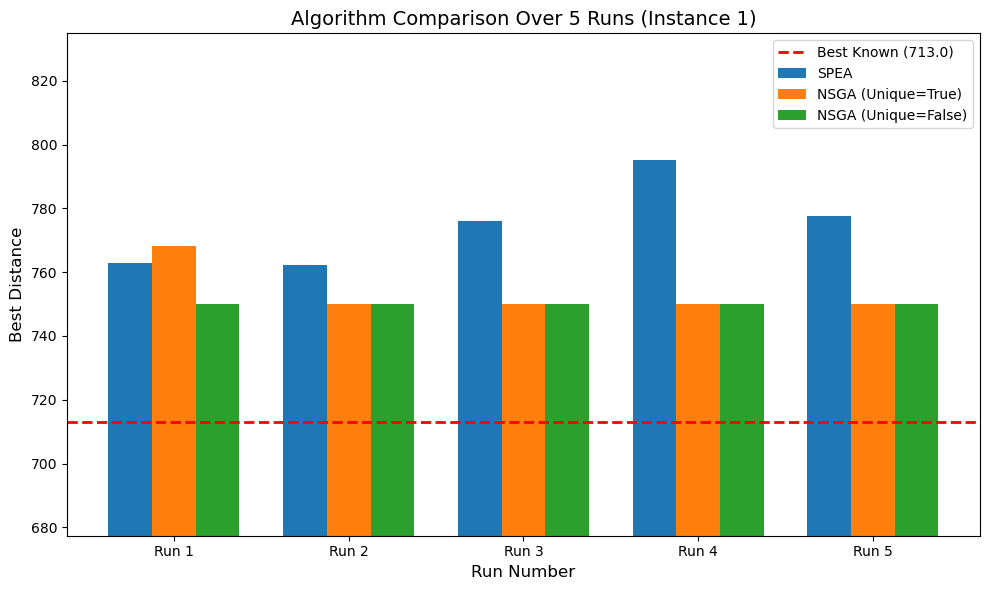

Running tests for Instance 4 over 5 runs...
Testing instance 4 using NSGA II (unique=True)
Average distance over 5 runs: 687.44 (best known: 651.0)
Average diff from known best: 5.30%
Best distance from all runs: 684.5688725260082
Best solution: [ 2  7  8 15 49]

Testing instance 4 using NSGA II (unique=False)
Average distance over 5 runs: 695.61 (best known: 651.0)
Average diff from known best: 6.41%
Best distance from all runs: 686.4120493034774
Best solution: [ 2  8 10 42 21]

Testing instance 4 using SPEA II
Average distance over 5 runs: 714.64 (best known: 651.0)
Average diff from known best: 8.90%
Best distance from all runs: 686.4120493034774
Best solution: (2, 8, 10, 21, 42)



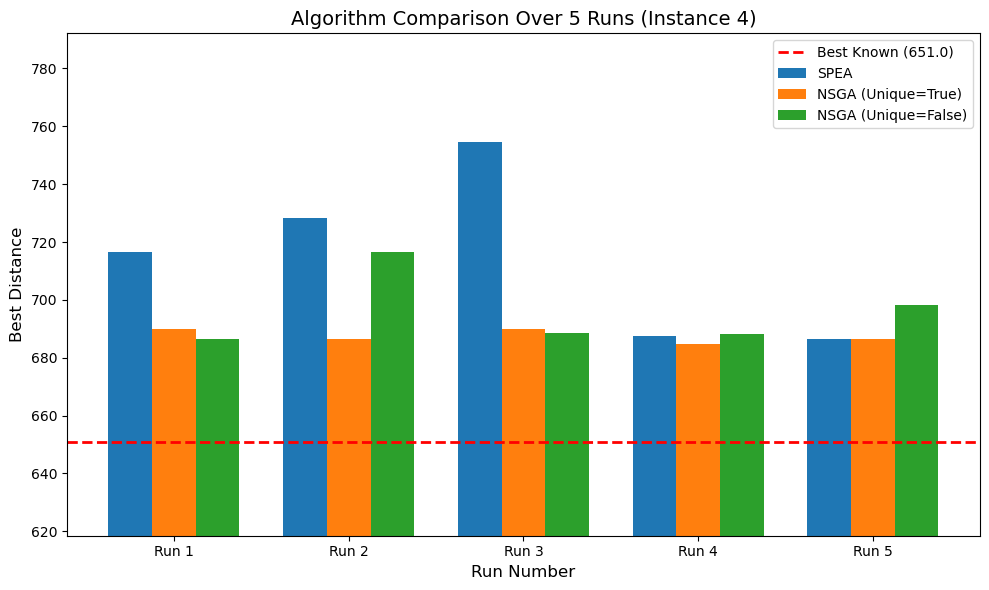

Running tests for Instance 5 over 5 runs...
Testing instance 5 using NSGA II (unique=True)
Average distance over 5 runs: 696.91 (best known: 664.0)
Average diff from known best: 4.72%
Best distance from all runs: 689.8729553107207
Best solution: [21 39 35 12 28]

Testing instance 5 using NSGA II (unique=False)
Average distance over 5 runs: 690.74 (best known: 664.0)
Average diff from known best: 3.87%
Best distance from all runs: 689.8729553107207
Best solution: [35 39 12 21 28]

Testing instance 5 using SPEA II
Average distance over 5 runs: 706.14 (best known: 664.0)
Average diff from known best: 5.97%
Best distance from all runs: 694.188241123523
Best solution: (12, 21, 35, 39, 43)



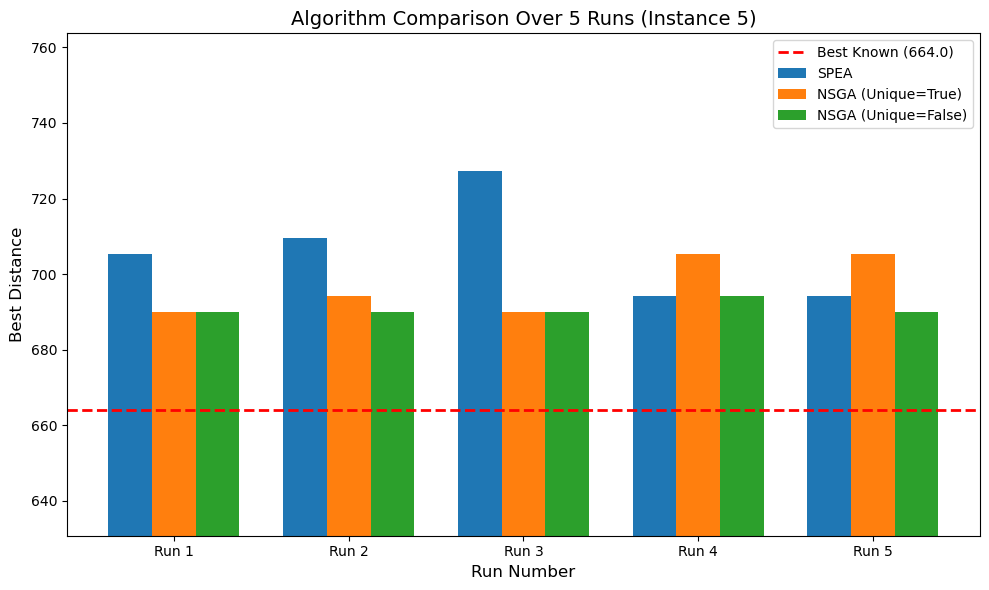

Running tests for Instance 9 over 5 runs...
Testing instance 9 using NSGA II (unique=True)
Average distance over 5 runs: 755.92 (best known: 715.0)
Average diff from known best: 5.41%
Best distance from all runs: 742.5348321252288
Best solution: [ 6 46 22 11 40]

Testing instance 9 using NSGA II (unique=False)
Average distance over 5 runs: 774.67 (best known: 715.0)
Average diff from known best: 7.70%
Best distance from all runs: 742.0231132133529
Best solution: [11  8 22  6 21]

Testing instance 9 using SPEA II
Average distance over 5 runs: 778.12 (best known: 715.0)
Average diff from known best: 8.11%
Best distance from all runs: 744.7016298295489
Best solution: (6, 8, 11, 22, 46)



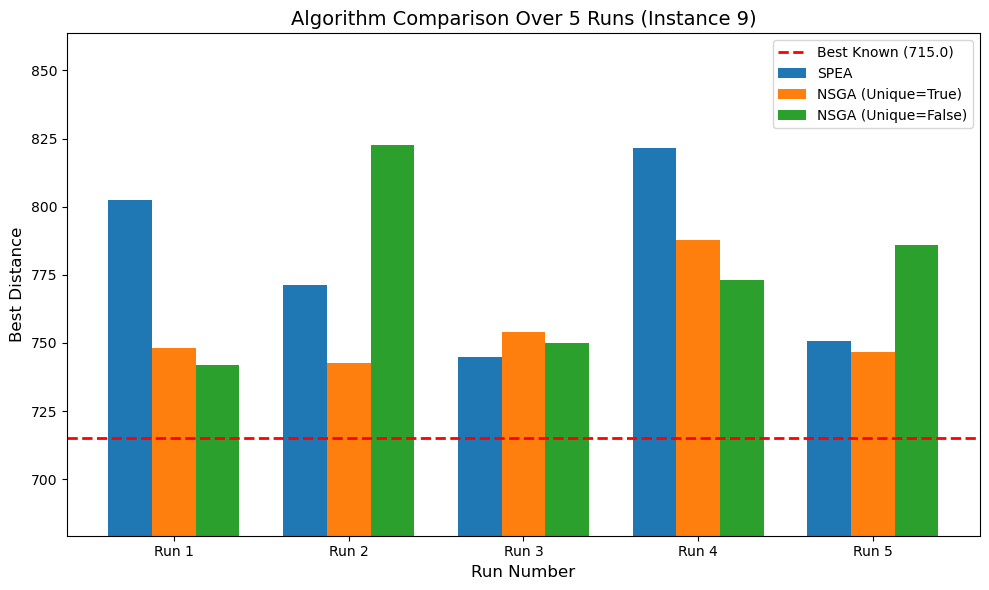

Running tests for Instance 16 over 5 runs...
Testing instance 16 using NSGA II (unique=True)
Average distance over 5 runs: 1114.07 (best known: 954.0)
Average diff from known best: 14.37%
Best distance from all runs: 1084.3290295256795
Best solution: [64  5 37 74 48 80 30 24 56 62]

Testing instance 16 using NSGA II (unique=False)
Average distance over 5 runs: 1075.28 (best known: 954.0)
Average diff from known best: 11.28%
Best distance from all runs: 1014.1655487169219
Best solution: [99 37 39  8 46 23 24 61 62 63]

Testing instance 16 using SPEA II
Average distance over 5 runs: 1104.66 (best known: 954.0)
Average diff from known best: 13.64%
Best distance from all runs: 1062.9925459766098
Best solution: (9, 24, 30, 43, 49, 63, 66, 67, 76, 99)



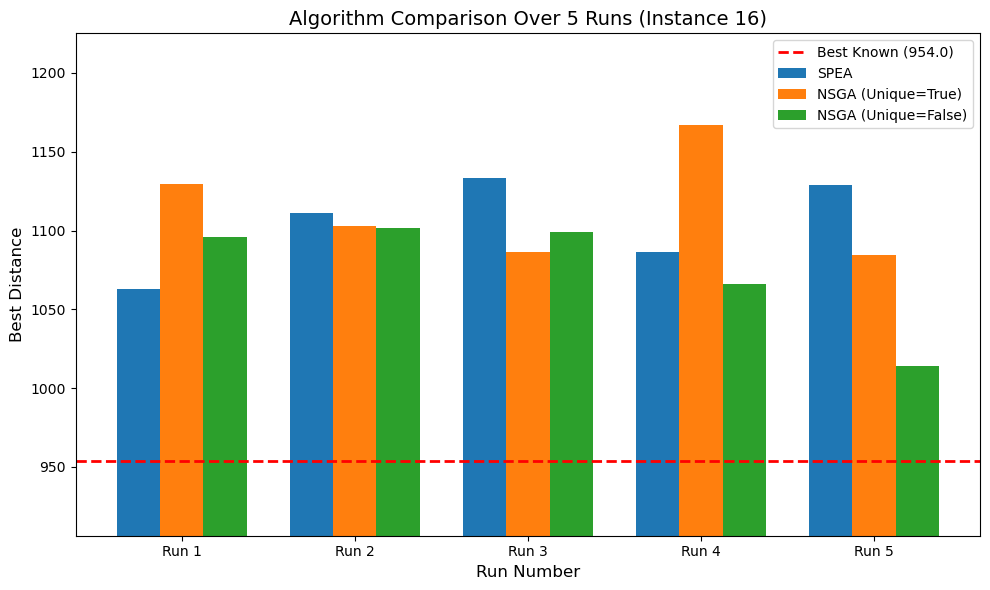

In [13]:
def plot_algorithm_comparison(runs, instance_idx):
    print(f"Running tests for Instance {instance_idx + 1} over {runs} runs...")
    
    # Extract the best known distance
    ins_key = sorted(instances.keys())[instance_idx]
    best_known = instances[ins_key].best_known

    # Run the algorithms and save the returned distances
    nsga_unique_dists = test_nsga(runs, instance=instance_idx, unique=True, quiet=True)
    nsga_non_unique_dists = test_nsga(runs, instance=instance_idx, unique=False, quiet=True)
    spea_dists = test_spea(runs, instance=instance_idx, quiet=True)

    # Setup the bar chart parameters
    x = np.arange(runs)  
    width = 0.25         

    # Create the figure
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the bars
    ax.bar(x - width, spea_dists, width, label='SPEA')
    ax.bar(x, nsga_unique_dists, width, label='NSGA (Unique=True)')
    ax.bar(x + width, nsga_non_unique_dists, width, label='NSGA (Unique=False)')

    # Add the horizontal reference line
    ax.axhline(y=best_known, color='r', linestyle='--', linewidth=2, label=f'Best Known ({best_known})')

    # Add labels, title, and custom x-axis tick labels
    ax.set_xlabel('Run Number', fontsize=12)
    ax.set_ylabel('Best Distance', fontsize=12)
    ax.set_title(f'Algorithm Comparison Over {runs} Runs (Instance {instance_idx+1})', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Run {i+1}' for i in range(runs)])

    # Adjust the Y-axis minimum to make the differences between bars more obvious
    min_val = min(min(spea_dists), min(nsga_unique_dists), min(nsga_non_unique_dists), best_known)
    ax.set_ylim(bottom=min_val * 0.95) 

    # Render the legend
    ax.legend()
    plt.tight_layout()

    plt.show()

plot_algorithm_comparison(5, 0)
plot_algorithm_comparison(5, 3)
plot_algorithm_comparison(5, 4)
plot_algorithm_comparison(5, 8)
plot_algorithm_comparison(5, 15)

# Conclusions
We can see that each algorithm perform better in different situations. No one of them is always better. When we tried to guarrantee unique children in the NSGA populations, we did not neccessarily improve the resulting best found. We believe that the population became too diverse and fails to hone in on the better solutions. However, the unique version of NSGA tends to be more consistent between runs giving similar results between runs.